In [1]:
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from scipy.signal import convolve
from scipy.ndimage import convolve1d
import seaborn as sns

In [165]:
subject1 = sc.io.loadmat("../data/s3.mat")
data1 = subject1['eeg']
data1 = data1.transpose(0,3,1,2)
print(np.shape(data1)) #(freq x trials x channels x points)

(12, 15, 8, 1114)


In [166]:
srate = 256
stim_freq = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]
stim_onset = 0.15
stim_onset_idx = 39

n_channels = 8
n_trials = 15
n_targets = 12
n_points = 1114

t_min = 0
t_max = 4
f_min = 8
f_max = 40

times = np.arange(n_points)/srate
chan_label = [""]

Signal Preprocessing step

In [167]:
iir_filter = dict(order=5, ftype='butter')
subject1data : list[mne.EpochsArray] = []

for i in range(n_targets):
    subject1data.append(
        mne.EpochsArray(
            data=data1[i,:,:,:],
            info = mne.create_info(n_channels, srate, ch_types='eeg'),
            verbose = False
        ).filter(l_freq = f_min, h_freq = f_max, method='iir', iir_params = iir_filter, verbose = True) # type: ignore
    )

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (e

Text(0, 0.5, 'Amplitude (microV)')

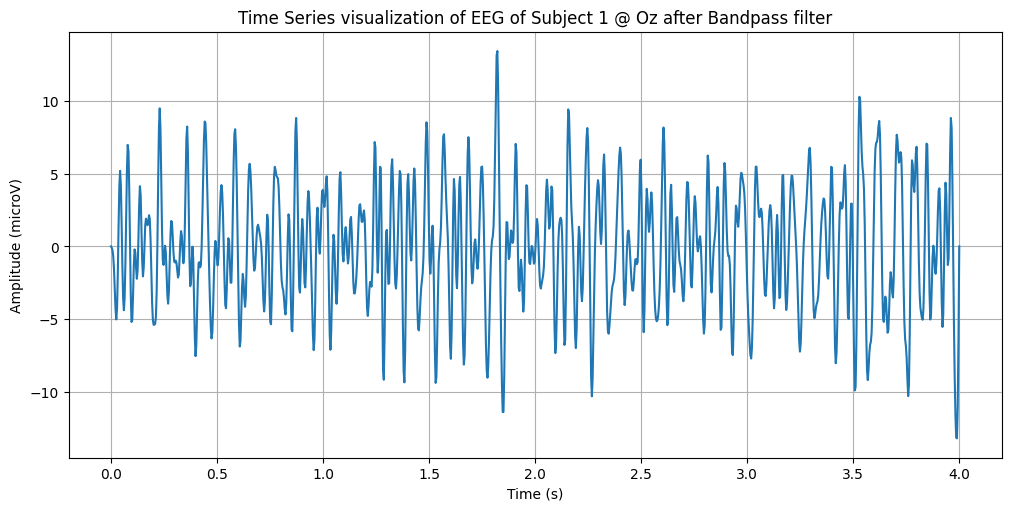

In [168]:
fig, ax = plt.subplots(figsize= (10,5), sharex=True, sharey=True, layout="constrained")
ax.plot(np.linspace(0, 4, 1114),subject1data[1].get_data()[1,7,:])
ax.grid(True)
ax.set_title("Time Series visualization of EEG of Subject 1 @ Oz after Bandpass filter")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (microV)")

In [169]:
corrected_subject1data = subject1data - np.mean(subject1data, axis=3, keepdims=True) # type: ignore
print(np.shape(corrected_subject1data))

(12, 15, 8, 1114)


## CCA

Reference Signals = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]

This time I will create reference signal by trial averaging 'p' epochs

In [200]:
TRAIN_SPLIT = 5
reference_signal = np.zeros([n_targets, n_channels, n_points])
for target_idx in range(n_targets):
    reference_signal[target_idx] = np.mean(corrected_subject1data[target_idx, :TRAIN_SPLIT,:,:], axis=0, keepdims=True)

print(np.shape(reference_signal))

(12, 8, 1114)


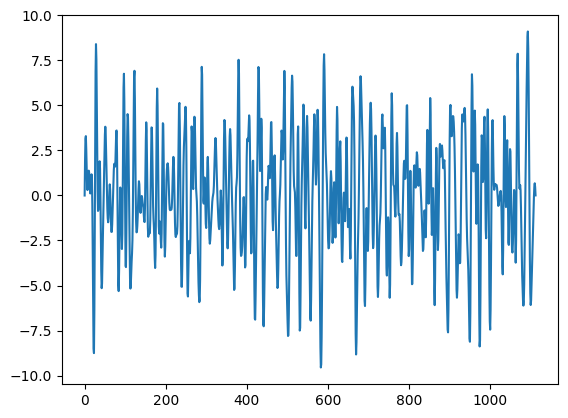

In [201]:
plt.plot(reference_signal[0][1])

In [202]:
#I'll now attempt to find covariance matrices
C_YY = reference_signal @ reference_signal.transpose(0,2,1)
print(np.shape(C_YY))

(12, 8, 8)


The idea is this, the dimension fo our data is (12, 15, 8, 1114). Now for every freq in  the first index, i should get a really high value when I CCA will 15 trials of that freq

In [203]:
print(np.shape(corrected_subject1data))

(12, 15, 8, 1114)


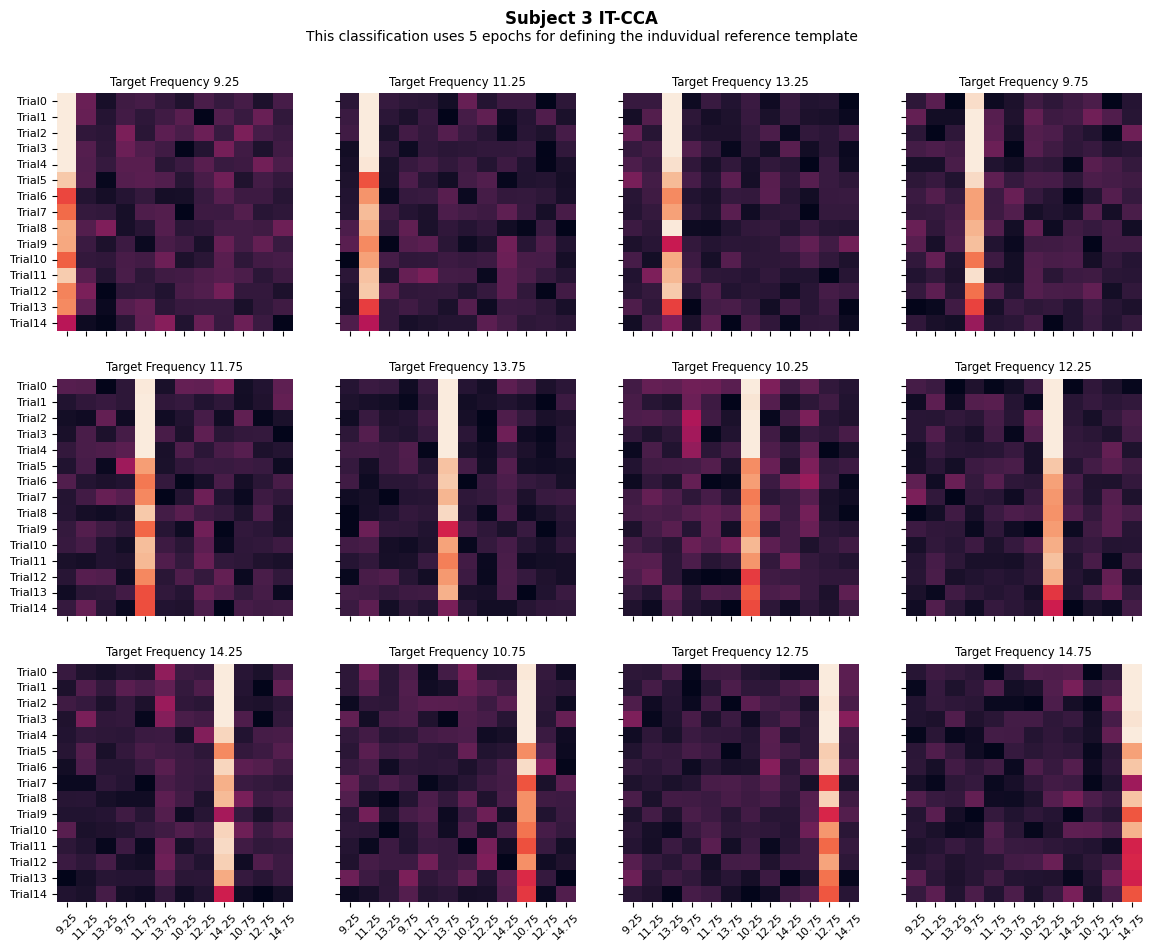

In [204]:
fig, axes = plt.subplots(3,4, figsize = (4*3.5, 3*3.5), sharex=True, sharey=True)
axes = axes.flatten()
fig.suptitle("Subject 3 IT-CCA", y = 0.96, fontweight="bold")
fig.text(0.5, 0.93, f"This classification uses {TRAIN_SPLIT} epochs for defining the induvidual reference template", ha="center")
xlabels = [str(f) for f in stim_freq]
ylabels = ["Trial" + str(i) for i in range(n_trials)]
for t_idx in range(n_targets):

    X = corrected_subject1data[t_idx]
    C_XX = X @ X.transpose(0,2,1)
    #print(np.shape(C_XX))
    #Einstein summ or whatever
    #(trials x channels x points) * (freq, harmonics, points) -> (trials, freq, channels, harmonics)
    C_XY = np.einsum('tck, fhk -> tfch', X, reference_signal)
    #print(np.shape(C_XY))
    RHO = np.zeros([n_trials, n_targets])
    for trial_idx in range(n_trials):
        for target_idx in range(n_targets):
            
            c_xx = C_XX[trial_idx]
            c_yy = C_YY[target_idx]
            c_xy = C_XY[trial_idx][target_idx]

            A = np.linalg.pinv(c_xx) @ c_xy @ np.linalg.pinv(c_yy) @ c_xy.T
            rho = np.linalg.eigvals(A)
            RHO[trial_idx][target_idx] = np.sqrt(np.max(rho.real))


    axes[t_idx].set_title(f"Target Frequency {stim_freq[t_idx]}", fontsize="small")
    sns.heatmap(RHO, robust=True, ax=axes[t_idx],cbar=False, xticklabels=xlabels, yticklabels=ylabels)
    plt.setp(axes[t_idx].get_yticklabels(), fontsize=8)
    plt.setp(axes[t_idx].get_xticklabels(), fontsize=8, rotation=45)